# A basic demo of exporting covariance matrices for a gas-phase mechanism

In [1]:
import rmgpy.chemkin
import copy
import rmgpy.tools.uncertainty
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
chemkin_file = './gas_example/chem_annotated.inp'
dict_file = './gas_example/species_dictionary.txt'

uncertainty = rmgpy.tools.uncertainty.Uncertainty()
uncertainty.load_model(chemkin_file, dict_file)


In [3]:
# Uncertainty database needs to match the input file that was used to generate the mechanism
uncertainty.load_database(
    kinetics_families=['default'],
    thermo_libraries=[
        'BurkeH2O2',
        'primaryThermoLibrary',
        'thermo_DFT_CCSDTF12_BAC',
        'DFT_QCI_thermo',
        'CBS_QB3_1dHR',
    ],
    reaction_libraries = [
        'BurkeH2O2inN2',
        'Klippenstein_Glarborg2016',
        'C2H4+O_Klipp2017',
        'FFCM1(-)',
        'CurranPentane',
        'combustion_core/version5',
    ]
)

ThermoData(Tdata=([300,400,500,600,800,1000,1500],'K'), Cpdata=([60.2599,68.0494,74.7775,80.9311,90.8846,97.4337,105.393],'J/(mol*K)'), H298=(-477.191,'kJ/mol'), S298=(269.551,'J/(mol*K)'), Cp0=(33.2579,'J/(mol*K)'), CpInf=(103.931,'J/(mol*K)'), comment="""Thermo group additivity estimation: group(O2s-(Cds-Cd)(Cds-Cd)) + group(O2s-(Cds-O2d)H) + group(Cds-OdOsOs) + group(Li-OCOdO) + radical(OC=OOJ)""").
The thermo for this species is probably wrong! Setting CpInf = Cphigh for Entropy calculationat T = 2000.0 K...


ThermoData(Tdata=([300,400,500,600,800,1000,1500],'K'), Cpdata=([60.2599,68.0494,74.7775,80.9311,90.8846,97.4337,105.393],'J/(mol*K)'), H298=(-477.191,'kJ/mol'), S298=(269.551,'J/(mol*K)'), Cp0=(33.2579,'J/(mol*K)'), CpInf=(103.931,'J/(mol*K)'), comment="""Thermo group additivity estimation: group(O2s-(Cds-Cd)(Cds-Cd)) + group(O2s-(Cds-O2d)H) + group(Cds-OdOsOs) + group(Li-OCOdO) + radical(OC=OOJ)""").
The thermo for this species is probably wrong! Setting CpInf = Cphigh for Entropy calculationat T = 1666.6666666666665 K...


In [4]:
# save uncorrelated results
uncertainty.extract_sources_from_model()
uncertainty.assign_parameter_uncertainties(correlated=False)

uncorrelated_thermo_uncertainties = copy.deepcopy(uncertainty.thermo_input_uncertainties)
uncorrelated_kinetics_uncertainties = copy.deepcopy(uncertainty.kinetic_input_uncertainties)

In [5]:
uncertainty.extract_sources_from_model()
uncertainty.assign_parameter_uncertainties(correlated=True)

In [6]:
# Make a thermo engine to be able to independently compute uncertainties
thermo_engine = rmgpy.tools.uncertainty.ThermoParameterUncertainty()
kinetics_engine = rmgpy.tools.uncertainty.KineticParameterUncertainty()


## Plot the correlated thermo covariance matrix and highlight a few examples

In [7]:
thermo_cov = uncertainty.get_thermo_covariance_matrix()

Text(0, 0.5, 'Species Index')

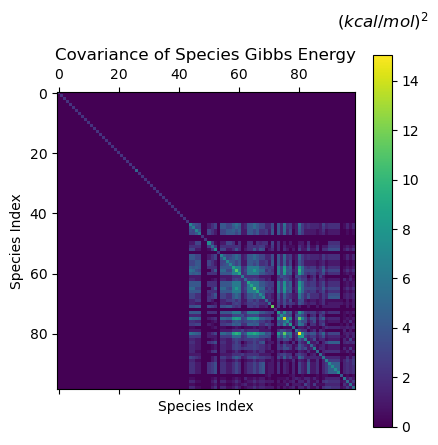

In [8]:
plt.matshow(thermo_cov)
plt.title('Covariance of Species Gibbs Energy')
cbar = plt.colorbar()
cbar.ax.set_title('$(kcal/mol)^2$\n')
plt.xlabel('Species Index')
plt.ylabel('Species Index')

### Covariance of a species with itself is the variance

In [9]:
for i in range(thermo_cov.shape[0]):
    # compare covariance matrix diagonal, which should match the standard deviation squared of the uncorrelated uncertainties
    assert np.isclose(thermo_cov[i, i], np.float_power(uncorrelated_thermo_uncertainties[i], 2.0))

In [10]:
i = 4

display(uncertainty.species_list[i])

print(uncertainty.species_list[i].thermo)
print()

assert thermo_engine.get_uncertainty_value(uncertainty.species_sources_dict[uncertainty.species_list[i]]) == uncorrelated_thermo_uncertainties[i]
std_dev = thermo_engine.get_uncertainty_value(uncertainty.species_sources_dict[uncertainty.species_list[i]])
print(f'Std-Dev(G_{i})\t= {std_dev:.3f} kcal/mol')
print(f'Var(G_{i})\t= {np.float_power(std_dev, 2.0):.3f} (kcal/mol)^2')
print(f'Cov(G_{i}, G_{i})\t= {thermo_cov[i, i]:.3f} (kcal/mol)^2')



NASA(polynomials=[NASAPolynomial(coeffs=[2.16919,0.0343904,-1.61558e-06,-1.30727e-08,5.17353e-12,-17250.5,14.6547], Tmin=(100,'K'), Tmax=(1147.6,'K')), NASAPolynomial(coeffs=[6.78902,0.0303598,-1.21262e-05,2.19945e-09,-1.5029e-13,-19105.8,-11.7328], Tmin=(1147.6,'K'), Tmax=(5000,'K'))], Tmin=(100,'K'), Tmax=(5000,'K'), comment="""Thermo library: DFT_QCI_thermo""")

Std-Dev(G_4)	= 1.500 kcal/mol
Var(G_4)	= 2.250 (kcal/mol)^2
Cov(G_4, G_4)	= 2.250 (kcal/mol)^2


### Library entries are assumed to be uncorrelated with each other

For example, butane and CH are both taken from the DFT_QCI_thermo, but because we don't have any correlation information about species within a library, we assume they are uncorrelated


In [11]:
i = 4
j = 6
display(uncertainty.species_list[i])
print(f'i={i}')
print(uncertainty.species_list[i].thermo)
print()
assert thermo_engine.get_uncertainty_value(uncertainty.species_sources_dict[uncertainty.species_list[i]]) == uncorrelated_thermo_uncertainties[i]
std_dev = thermo_engine.get_uncertainty_value(uncertainty.species_sources_dict[uncertainty.species_list[i]])
print(f'Std-Dev(G_{i})\t= {std_dev:.3f} kcal/mol')
print(f'Var(G_{i})\t= {np.float_power(std_dev, 2.0):.3f} (kcal/mol)^2')
print(f'Cov(G_{i}, G_{i})\t= {thermo_cov[i, i]:.3f} (kcal/mol)^2')
print('------------------------------------------------------------')
print()
print(f'j={j}')
display(uncertainty.species_list[j])
print(uncertainty.species_list[j].thermo)
print()
assert thermo_engine.get_uncertainty_value(uncertainty.species_sources_dict[uncertainty.species_list[j]]) == uncorrelated_thermo_uncertainties[j]
std_dev = thermo_engine.get_uncertainty_value(uncertainty.species_sources_dict[uncertainty.species_list[j]])
print(f'Std-Dev(G_{j})\t= {std_dev:.3f} kcal/mol')
print(f'Var(G_{j})\t= {np.float_power(std_dev, 2.0):.3f} (kcal/mol)^2')
print(f'Cov(G_{j}, G_{j})\t= {thermo_cov[j, j]:.3f} (kcal/mol)^2')
print('------------------------------------------------------------')
print()
print(f'Cov(G_{i}, G_{j})\t= {thermo_cov[i, j]:.3f} (kcal/mol)^2')

i=4
NASA(polynomials=[NASAPolynomial(coeffs=[2.16919,0.0343904,-1.61558e-06,-1.30727e-08,5.17353e-12,-17250.5,14.6547], Tmin=(100,'K'), Tmax=(1147.6,'K')), NASAPolynomial(coeffs=[6.78902,0.0303598,-1.21262e-05,2.19945e-09,-1.5029e-13,-19105.8,-11.7328], Tmin=(1147.6,'K'), Tmax=(5000,'K'))], Tmin=(100,'K'), Tmax=(5000,'K'), comment="""Thermo library: DFT_QCI_thermo""")

Std-Dev(G_4)	= 1.500 kcal/mol
Var(G_4)	= 2.250 (kcal/mol)^2
Cov(G_4, G_4)	= 2.250 (kcal/mol)^2
------------------------------------------------------------

j=6


NASA(polynomials=[NASAPolynomial(coeffs=[3.53296,-5.8434e-05,-6.75232e-07,1.93806e-09,-9.35363e-13,70568,1.86651], Tmin=(100,'K'), Tmax=(971.4,'K')), NASAPolynomial(coeffs=[2.74761,0.00151397,-5.37645e-07,8.28614e-11,-4.75184e-15,70798.9,6.03609], Tmin=(971.4,'K'), Tmax=(5000,'K'))], Tmin=(100,'K'), Tmax=(5000,'K'), comment="""Thermo library: DFT_QCI_thermo""")

Std-Dev(G_6)	= 1.500 kcal/mol
Var(G_6)	= 2.250 (kcal/mol)^2
Cov(G_6, G_6)	= 2.250 (kcal/mol)^2
------------------------------------------------------------

Cov(G_4, G_6)	= 0.000 (kcal/mol)^2


### When species use the same Benson group, the off diagonal value will be nonzero

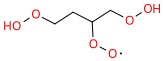

i=80


{'GAV': {'group': [(<Entry index=2335 label="O2s-OsCs">, 3),
   (<Entry index=2317 label="O2s-OsH">, 3),
   (<Entry index=1908 label="Cs-CsCsOsH">, 1),
   (<Entry index=953 label="Cs-CsCsHH">, 1),
   (<Entry index=1952 label="Cs-CsOsHH">, 2)],
  'radical': [(<Entry index=1872 label="ROOJ">, 1)]}}


Std-Dev(G_80)	= 3.881 kcal/mol
Var(G_80)	= 15.063 (kcal/mol)^2
Cov(G_80, G_80)	= 15.063 (kcal/mol)^2
------------------------------------------------------------

j=78


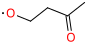

{'GAV': {'group': [(<Entry index=2327 label="O2s-CsH">, 1),
   (<Entry index=955 label="Cs-(Cds-O2d)CsHH">, 1),
   (<Entry index=1952 label="Cs-CsOsHH">, 1),
   (<Entry index=923 label="Cs-(Cds-O2d)HHH">, 1),
   (<Entry index=264 label="Cds-OdCsCs">, 1)],
  'radical': [(<Entry index=1808 label="CCOJ">, 1)]}}


Std-Dev(G_78)	= 2.308 kcal/mol
Var(G_78)	= 5.325 (kcal/mol)^2
Cov(G_78, G_78)	= 5.325 (kcal/mol)^2
------------------------------------------------------------

Cov(G_80, G_78)	= 1.025 (kcal/mol)^2 <------------------- off-diagonal is non-zero


In [12]:
i = 80
j = 78
display(uncertainty.species_list[i])
print(f'i={i}')
display(uncertainty.species_sources_dict[uncertainty.species_list[i]])
print()
assert thermo_engine.get_uncertainty_value(uncertainty.species_sources_dict[uncertainty.species_list[i]]) == uncorrelated_thermo_uncertainties[i]
std_dev = thermo_engine.get_uncertainty_value(uncertainty.species_sources_dict[uncertainty.species_list[i]])
print(f'Std-Dev(G_{i})\t= {std_dev:.3f} kcal/mol')
print(f'Var(G_{i})\t= {np.float_power(std_dev, 2.0):.3f} (kcal/mol)^2')
print(f'Cov(G_{i}, G_{i})\t= {thermo_cov[i, i]:.3f} (kcal/mol)^2')
print('------------------------------------------------------------')
print()
print(f'j={j}')
display(uncertainty.species_list[j])
display(uncertainty.species_sources_dict[uncertainty.species_list[j]])
print()
assert thermo_engine.get_uncertainty_value(uncertainty.species_sources_dict[uncertainty.species_list[j]]) == uncorrelated_thermo_uncertainties[j]
std_dev = thermo_engine.get_uncertainty_value(uncertainty.species_sources_dict[uncertainty.species_list[j]])
print(f'Std-Dev(G_{j})\t= {std_dev:.3f} kcal/mol')
print(f'Var(G_{j})\t= {np.float_power(std_dev, 2.0):.3f} (kcal/mol)^2')
print(f'Cov(G_{j}, G_{j})\t= {thermo_cov[j, j]:.3f} (kcal/mol)^2')
print('------------------------------------------------------------')
print()
print(f'Cov(G_{i}, G_{j})\t= {thermo_cov[i, j]:.3f} (kcal/mol)^2 <------------------- off-diagonal is non-zero')

### Plot the kinetics covariance matrix

In [13]:
# This can take a minute
kinetics_cov = uncertainty.get_kinetic_covariance_matrix()

Text(0, 0.5, 'Reaction Index')

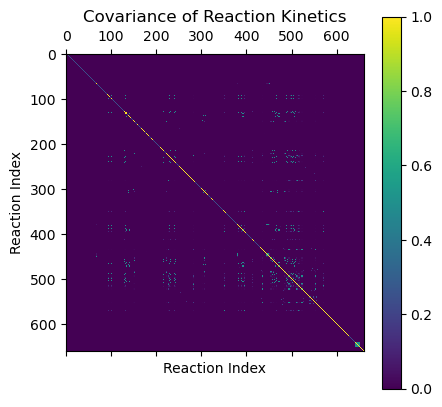

In [14]:
plt.matshow(kinetics_cov)
plt.title('Covariance of Reaction Kinetics')
cbar = plt.colorbar()
plt.clim([0, 1.0])
plt.xlabel('Reaction Index')
plt.ylabel('Reaction Index')

### Covariance of a reaction with itself is the variance

In [15]:
for i in range(kinetics_cov.shape[0]):
    if not np.isclose(kinetics_cov[i, i], np.float_power(uncorrelated_kinetics_uncertainties[i], 2.0)):
        print(i)
    # if i in [66, 67, 91, 93]:
    #     continue
    # # compare covariance matrix diagonal, which should match the standard deviation squared of the uncorrelated uncertainties
    # assert np.isclose(kinetics_cov[i, i], np.float_power(uncorrelated_kinetics_uncertainties[i], 2.0)), i

66
67
91
93
94
99
100
103
104
128
129
130
131
132
133
138
139
140
141
148
149
150
151
152
167
168
169
170
177
178
179
189
191
201
205
208
212
214
215
221
222
227
228
229
230
231
232
237
239
240
241
242
250
251
252
253
265
266
276
282
283
300
301
302
303
304
305
306
307
308
311
312
324
351
352
379
380
382
383
384
386
387
388
389
390
391
392
393
394
395
413
414
430
431
433
435
436
437
438
439
440
441
442
443
444
445
446
447
448
449
450
451
452
453
454
455
456
457
458
459
460
461
462
463
464
465
466
467
468
469
470
471
472
473
474
475
476
477
478
480
481
482
483
484
485
486
487
488
489
490
491
492
493
494
495
496
497
498
499
500
501
502
503
504
505
506
507
508
509
510
511
512
513
514
515
516
517
520
521
522
523
525
526
527
528
529
530
531
532
533
534
535
536
541
542
543
544
545
546
547
548
549
550
552
553
554
555
556
558
560
561
562
563
564
565
566
567
568
569
570
571
618
640
641
643
644
645
646
647
648
649
650


### Kinetics that use the same rate rule/autogenerated tree node will have non-zero off-diagonals

In [16]:
i = 500
j = 501
display(uncertainty.reaction_list[i])
print(f'i={i}')
display(uncertainty.reaction_sources_dict[uncertainty.reaction_list[i]])
print()
assert kinetics_engine.get_uncertainty_value(uncertainty.reaction_sources_dict[uncertainty.reaction_list[i]]) == uncorrelated_kinetics_uncertainties[i]
std_dev = kinetics_engine.get_uncertainty_value(uncertainty.reaction_sources_dict[uncertainty.reaction_list[i]])
print(f'Std-Dev(lnk_{i})\t= {std_dev:.3f}')
print(f'Var(lnk_{i})\t= {np.float_power(std_dev, 2.0):.3f}')
print(f'Cov(lnk_{i}, lnk_{i})\t= {kinetics_cov[i, i]:.3f}')
print('------------------------------------------------------------')
print()
print(f'j={j}')
display(uncertainty.reaction_list[j])
display(uncertainty.reaction_sources_dict[uncertainty.reaction_list[j]])
print()
assert kinetics_engine.get_uncertainty_value(uncertainty.reaction_sources_dict[uncertainty.reaction_list[j]]) == uncorrelated_kinetics_uncertainties[j]
std_dev = kinetics_engine.get_uncertainty_value(uncertainty.reaction_sources_dict[uncertainty.reaction_list[j]])
print(f'Std-Dev(lnk_{j})\t= {std_dev:.3f}')
print(f'Var(lnk_{j})\t= {np.float_power(std_dev, 2.0):.3f}')
print(f'Cov(lnk_{j}, lnk_{j})\t= {kinetics_cov[j, j]:.3f}')
print('------------------------------------------------------------')
print()
print(f'Cov(lnk_{i}, lnk_{j})\t= {kinetics_cov[i, j]:.3f} <------------------- off-diagonal is non-zero')

i=500


{'Rate Rules': ['Disproportionation',
  {'template': [<Entry index=54 label="Root_Ext-1R!H-R_N-4R->O_N-Sp-5R!H=1R!H_Ext-4CHNS-R_N-6R!H->S_4CHNS->C_N-Sp-6BrBrBrCCCClClClFFFIIINNNOOOPPPSiSiSi#4C_6BrCClFINOPSi->C_N-1R!H-inRing_Sp-6C-4C_Ext-6C-R">],
   'degeneracy': 2.0,
   'exact': False,
   'rules': [(<Entry index=228 label="Root_Ext-1R!H-R_N-4R->O_N-Sp-5R!H=1R!H_Ext-4CHNS-R_N-6R!H->S_4CHNS->C_N-Sp-6BrBrBrCCCClClClFFFIIINNNOOOPPPSiSiSi#4C_6BrCClFINOPSi->C_N-1R!H-inRing_Sp-6C-4C_Ext-6C-R">,
     1)],
   'training': [],
   'autogenerated': True,
   'node_std_dev': 11.540182761524994,
   'node_n_train': 1}]}


Std-Dev(lnk_500)	= 11.631
Var(lnk_500)	= 135.286
Cov(lnk_500, lnk_500)	= 4.717
------------------------------------------------------------

j=501


{'Rate Rules': ['Disproportionation',
  {'template': [<Entry index=54 label="Root_Ext-1R!H-R_N-4R->O_N-Sp-5R!H=1R!H_Ext-4CHNS-R_N-6R!H->S_4CHNS->C_N-Sp-6BrBrBrCCCClClClFFFIIINNNOOOPPPSiSiSi#4C_6BrCClFINOPSi->C_N-1R!H-inRing_Sp-6C-4C_Ext-6C-R">],
   'degeneracy': 2.0,
   'exact': False,
   'rules': [(<Entry index=228 label="Root_Ext-1R!H-R_N-4R->O_N-Sp-5R!H=1R!H_Ext-4CHNS-R_N-6R!H->S_4CHNS->C_N-Sp-6BrBrBrCCCClClClFFFIIINNNOOOPPPSiSiSi#4C_6BrCClFINOPSi->C_N-1R!H-inRing_Sp-6C-4C_Ext-6C-R">,
     1)],
   'training': [],
   'autogenerated': True,
   'node_std_dev': 11.540182761524994,
   'node_n_train': 1}]}


Std-Dev(lnk_501)	= 11.631
Var(lnk_501)	= 135.286
Cov(lnk_501, lnk_501)	= 4.717
------------------------------------------------------------

Cov(lnk_500, lnk_501)	= 0.500 <------------------- off-diagonal is non-zero
